Code example for a 4 qubit PST system that saves the hardware results to a directory for future reference and plots the relevant graphs.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from pathlib import Path
import pickle
from braket.circuits import Circuit
from braket.devices import LocalSimulator
from braket.aws import AwsDevice

In [ ]:
folder_path = r"Folder\Hardware Data\hardwaredata_N4_optimal_int_firstorder_400shots"


file_pattern = os.path.join(folder_path, "time_*.txt")
files = glob.glob(file_pattern)

if not files:
    raise FileNotFoundError(f"No files found at {file_pattern}")



In [5]:
intended_states = ["1000", "0100", "0010", "0001"]

all_data = []

In [6]:
for file in files:
    df = pd.read_csv(file, sep=r'\s+', engine='python')
    
    if 'time' not in df.columns:
        continue

    row_dict = df.iloc[0].to_dict()
    all_data.append(row_dict)
master_df = pd.DataFrame(all_data).sort_values(by='time').fillna(0.0)


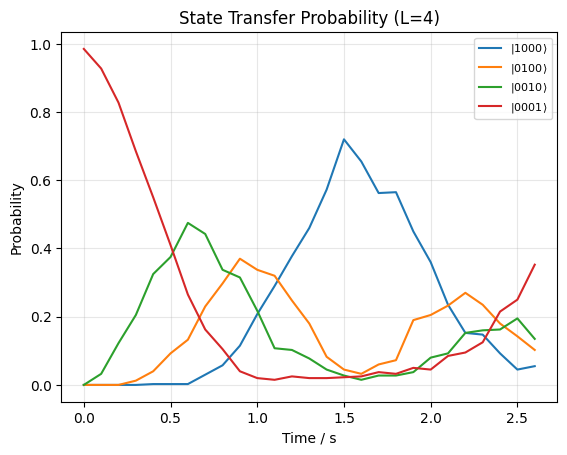

In [ ]:
# Plot raw data
for col in intended_states:
    if col in master_df.columns:
        plt.plot(
            master_df['time'], 
            master_df[col], 
            label=f"$|{col}\\rangle$",  
        )
    else:
        print(f"Warning: State {col} not found in the data files.")

plt.xlabel("Time / s")
plt.ylabel("Probability")
plt.title("State Transfer Probability (L=4)")
plt.legend(fontsize=8, loc="best")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Process of normalising the data by disregarding bit flip errors
time = master_df['time'].values
eps = 1e-12

P_1p = master_df[intended_states].sum(axis=1).values

In [9]:
renorm_data = {}
for state in intended_states:
    renorm_data[f"{state}_ren"] = master_df[state].values / (P_1p + eps)


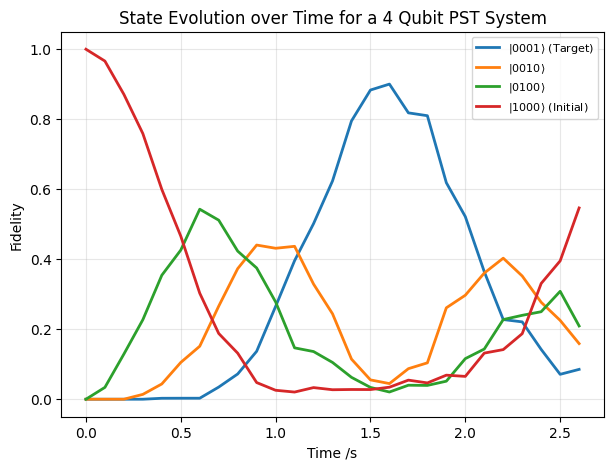

In [ ]:
# Plot renormalised data
labels = {
    "1000": r"$|0001\rangle$ (Target)",
    "0100": r"$|0010\rangle$",
    "0010": r"$|0100\rangle$",
    "0001": r"$|1000\rangle$ (Initial)"
}
plt.figure(figsize=(7,5))
for state in intended_states:
    plt.plot(time, renorm_data[f"{state}_ren"], lw=2, label=labels.get(state, state))


plt.xlabel("Time /s")
plt.ylabel("Fidelity")
plt.title(f"State Evolution over Time for a 4 Qubit PST System")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)

plt.show()



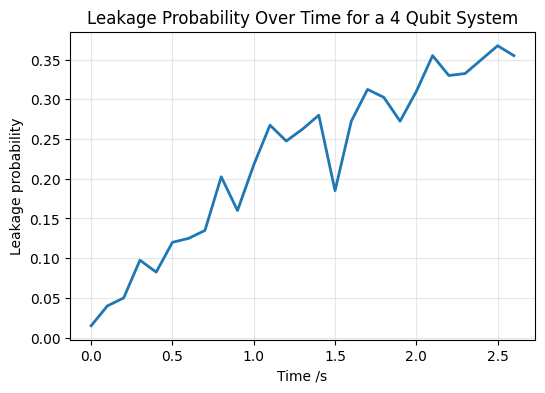

In [ ]:
# Plot leakeage (error accumulation) over time 
P_leak = 1.0 - P_1p
plt.figure(figsize=(6,4))
plt.plot(time, P_leak, lw=2)
plt.title("Leakage Probability Over Time for a 4 Qubit System")
plt.xlabel("Time /s")
plt.ylabel("Leakage probability")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Save the data
out_dir = Path(r"Folder\Hardware Data")
out_dir.mkdir(parents=True, exist_ok=True)

np.savez(
    out_dir / "fidelity_data400shots_Optimal_L4_renorm.npz",
    time=time,
    P_1000_ren=renorm_data["1000_ren"],
    P_0100_ren=renorm_data["0100_ren"],
    P_0010_ren=renorm_data["0010_ren"],
    P_0001_ren=renorm_data["0001_ren"],
    P_leak=P_leak
)

print(f"File saved successfully to: {out_dir / 'fidelity_data400shots_Optimal_L4_renorm.npz'}")


In [13]:
np.savez(
    out_dir / "leakage_Optimal_L4.npz", 
    time=time, 
    P_leak=P_leak
)

Final Graph

In [ ]:
N_QUBITS = 4

os.environ["AWS_ACCESS_KEY_ID"]="access key ID"
os.environ["AWS_SECRET_ACCESS_KEY"]="access key"
os.environ["AWS_SESSION_TOKEN"]= "session token"
os.environ["AWS_DEFAULT_REGION"] = "region"
USE_IONQ_QPU = False


# XY interaction
def xy_interaction(circuit, q1, q2, theta):
    circuit.xx(q1, q2, theta)
    circuit.rz(q1, np.pi / 2)
    circuit.rz(q2, np.pi / 2)
    circuit.xx(q1, q2, theta)
    circuit.rz(q1, -np.pi / 2)
    circuit.rz(q2, -np.pi / 2)

# Trotter circuit
def xy_trotter_circuit(
    n_qubits=3,
    J_in=-2.0,
    total_time=1.8,
    dt=0.1
):

    trotter_steps = int(total_time / dt)

    circuit = Circuit()

    # Initial state |00...01>
    circuit.x(n_qubits - 1)

    J_n = np.zeros(n_qubits - 1)

    for n in range(1, n_qubits):

        if n_qubits % 2 == 0:
            J = (2.0 / n_qubits) * np.sqrt(n * (n_qubits - n))
        else:
            J = (2.0 / np.sqrt(n_qubits**2 - 1)) * np.sqrt(n * (n_qubits - n))

        J_n[n - 1] = J_in * J

    # Apply Trotter steps
    for _ in range(trotter_steps):
        for i in range(n_qubits - 1):
            J_ij = J_n[i]
            theta = J_ij * dt
            xy_interaction(circuit, i, i + 1, theta)

    return circuit

# Run simulation
tasks = []
times_MS = []

dt = 0.1

for time in range(0, 30, 1):
    time2 = time * 0.1

    circuit = xy_trotter_circuit(
        n_qubits=N_QUBITS,
        total_time=time2,
        dt=dt
    )

    # add measurements
    for q in range(N_QUBITS):
        circuit.measure(q)

    times_MS.append(time2)

    device = LocalSimulator()
    print("\n[LOCAL SIMULATOR MODE]")


    task = device.run(circuit,shots=400)
    tasks.append(task)

    print("Batch submission COMPLETE.")
    print("No per-circuit execution happening here.\n")

# Get results
fidelities = []

print("Retrieving results...\n")

for time2, task in zip(times_MS, tasks):
    result = task.result()
    counts = result.measurement_counts
    fidelity = (counts.get("1000", 0)) / sum(counts.values())
    fidelities.append(fidelity)

    print(
        f"[RESULT] t = {time2:.2f} | fidelity = {fidelity:.3f}")




[LOCAL SIMULATOR MODE]
Batch submission COMPLETE.
No per-circuit execution happening here.


[LOCAL SIMULATOR MODE]
Batch submission COMPLETE.
No per-circuit execution happening here.


[LOCAL SIMULATOR MODE]
Batch submission COMPLETE.
No per-circuit execution happening here.


[LOCAL SIMULATOR MODE]
Batch submission COMPLETE.
No per-circuit execution happening here.


[LOCAL SIMULATOR MODE]
Batch submission COMPLETE.
No per-circuit execution happening here.


[LOCAL SIMULATOR MODE]
Batch submission COMPLETE.
No per-circuit execution happening here.


[LOCAL SIMULATOR MODE]
Batch submission COMPLETE.
No per-circuit execution happening here.


[LOCAL SIMULATOR MODE]
Batch submission COMPLETE.
No per-circuit execution happening here.


[LOCAL SIMULATOR MODE]
Batch submission COMPLETE.
No per-circuit execution happening here.


[LOCAL SIMULATOR MODE]
Batch submission COMPLETE.
No per-circuit execution happening here.


[LOCAL SIMULATOR MODE]
Batch submission COMPLETE.
No per-circuit exec

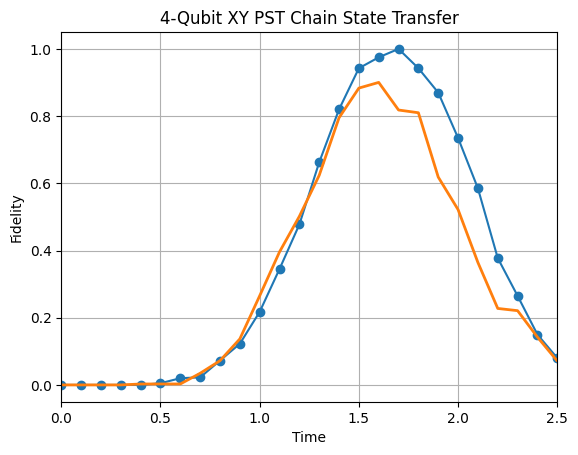

In [ ]:
# Plot
state = "1000"
time = master_df['time'].values
plt.figure()
plt.plot(times_MS, fidelities, marker='o')
plt.plot(time,  renorm_data[f"{state}_ren"], lw=2)
plt.xlim(0,2.5)
plt.xlabel("Time")
plt.ylabel("Fidelity")
plt.title(f"{N_QUBITS}-Qubit XY PST Chain State Transfer")
plt.grid(True)
plt.show()

In [ ]:
# Plot against saved simulations from Final_Script
# Parameters
s = N_QUBITS
total_time = 6
J_in = 1.0
alpha = 5
ns_str = "5-20-50-100"

old_dir =Path(
    r"Folder"
)

# Load simulation file
pkl_file = old_dir / f"simulation_L{s}_T{total_time}_J{J_in}_a{alpha}_ns{ns_str}.pkl"
if not pkl_file.exists():
    raise FileNotFoundError(f"Could not find {pkl_file}")

with open(pkl_file, "rb") as f:
    r = pickle.load(f)

print(f"Loaded simulation file: {pkl_file}")


In [17]:
# Extract PST data from pkl
t_exact = np.array(r["exact"]["PST"]["times"])
F_exact = np.array(r["exact"]["PST"]["F"])
peak_times_exact = np.array(r["exact"]["PST"]["peak_times"])
peak_values_exact = np.array(r["exact"]["PST"]["peak_values"])


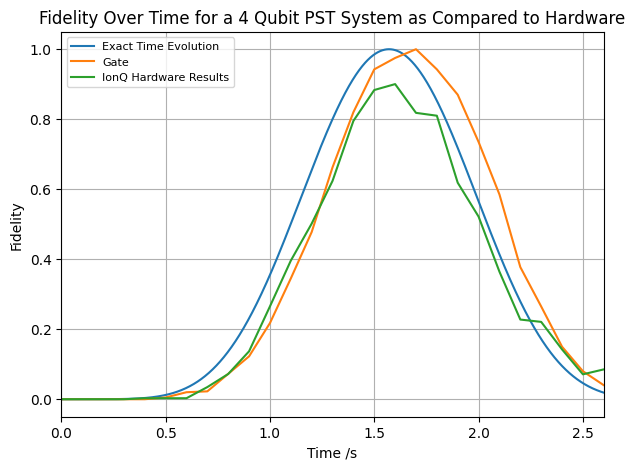

In [ ]:
# Plot all data
plt.figure(figsize=(7,5))
plt.plot(t_exact, F_exact, label="Exact Time Evolution")
plt.plot(times_MS, fidelities, label=f"Gate")
plt.plot(time,  renorm_data[f"{state}_ren"],  label="IonQ Hardware Results")
plt.xlim(0,time[-1])
plt.xlabel("Time /s")
plt.ylabel("Fidelity")
plt.title(f"Fidelity Over Time for a {N_QUBITS} Qubit PST System as Compared to Hardware")
plt.grid(True)
plt.legend(fontsize=8, loc="best")
plt.show()

In [30]:
dt = 0.1
times_NN = np.arange(0, 2.7, dt)
fidelities_NN = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.03, 0.0425, 0.11, 0.195, 0.3575, 0.4675, 0.655, 0.835, 0.9425, 0.9825, 0.9275, 0.8325, 0.7225, 0.485, 0.33, 0.1525, 0.04, 0.0025, 0.0025, 0.0225, 0.08]

In [ ]:
# Load NN system hardware data
DATA_DIR = Path(
    r"Folder\Hardware Data"
)

data_NN = np.load(DATA_DIR / f"fidelity_data400shots_L{s}_renorm.npz")

key_initial = f"P_1{'0' * (s - 1)}_ren"

time_NN = data_NN["time"]
P_NNinitial = data_NN[key_initial]

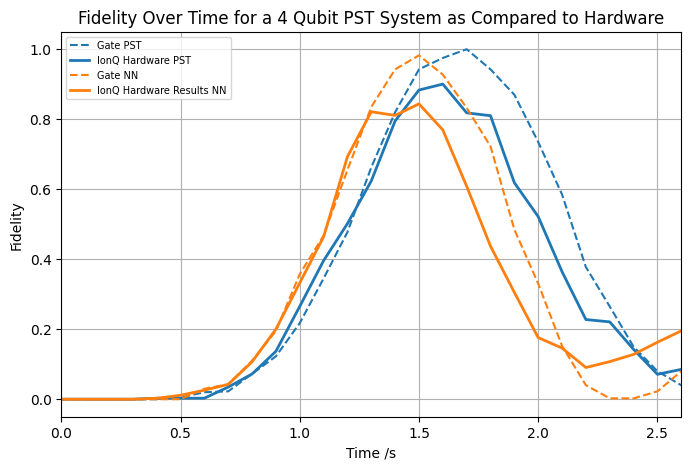

In [ ]:
# Plot PST & NN
plt.figure(figsize=(8,5))

plt.plot(times_MS, fidelities, color='#1f77b4', linestyle='--', label="Gate PST")
plt.plot(time,  renorm_data[f"{state}_ren"], color='#1f77b4', lw=2, label="IonQ Hardware PST")

plt.plot(times_NN, fidelities_NN, color='#ff7f0e', linestyle='--', label="Gate NN")
plt.plot(time_NN, P_NNinitial, color='#ff7f0e', lw=2, label="IonQ Hardware Results NN")




plt.xlim(0,time_NN[-1])
plt.xlabel("Time /s")
plt.ylabel("Fidelity")
plt.title(f"Fidelity Over Time for a {s} Qubit System as Compared to Hardware")
plt.legend(fontsize=7, loc="best")
plt.grid(True)
plt.show()